# Imports 

In [1]:
import os
import re
import csv
import zipfile

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from sklearn.model_selection import (
    StratifiedKFold,
    train_test_split,
    KFold,
    cross_val_score,
)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    roc_curve,
    auc,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier

# Functions

# Datasets

In [2]:
path = "../../Data_Processing/outputs/banks_y9c"

In [3]:
df_9c = pd.concat(
    [
        pd.read_pickle(os.path.join(path, file))
        for file in os.listdir(path)
        # if "df_banks_part_" in file
    ],
    axis=0,
).reset_index(drop=True)

## Target variable definition

In [13]:
df_9c_sorted = df_9c[
    sorted(df_9c.columns, key=lambda c: (not c[0].islower(), c.lower(), c))
].sort_values(by=["id", "quarter"])

In [14]:
def value_x_quarters_before(
    df: pd.DataFrame, quarter: str, nr_quarters_before: int, value_col: str
):
    """
    Returns the values x quarters before a target quarter for any given column.

    Parameters:
        df (pd.DataFrame): DataFrame with columns ['id', 'year', 'nr_quarter', ...].
        quarter (str): Target quarter YYYYMMDD.
        nr_quarters_before (int): Number of quarters to go back.
        value_col (str): Name of the column to retrieve values for.

    Returns:
        pd.DataFrame: DataFrame with columns ['id', 'year', 'nr_quarter', f'{value_col}_x_quarters_before']
    """

    target_year = int(quarter[:4])
    target_month = int(quarter[4:6])
    target_quarter = ((target_month - 1) // 3) + 1

    # Compute the target quarter’s "absolute quarter number"
    target_abs_quarter = target_year * 4 + target_quarter

    # Compute the quarter to look for
    desired_abs_quarter = target_abs_quarter - nr_quarters_before

    # Convert abs_quarter back to year and quarter
    desired_year = desired_abs_quarter // 4
    desired_quarter = desired_abs_quarter % 4
    if desired_quarter == 0:
        desired_year -= 1
        desired_quarter = 4

    # Filter for desired quarter
    result = df[
        (df["year"] == desired_year) & (df["nr_quarter"] == desired_quarter)
    ].copy()

    return result[["id", "year", "nr_quarter", value_col]]

In [15]:
def k_fold_acc_precision_recall(X_train, y_train, pipeline, n_splits, threshold):
    """
    Perform K-fold evaluation using a Pipeline (imputer + scaler + logistic regression).
    Returns overall metrics and per-fold results.
    """

    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    fold_results = []

    for fold, (train_idx, test_idx) in enumerate(kf.split(X_train, y_train), 1):
        X_tr, X_te = X_train[train_idx], X_train[test_idx]
        y_tr, y_te = y_train[train_idx], y_train[test_idx]

        # Fit the entire pipeline on this fold
        pipeline.fit(X_tr, y_tr)

        # Predict probabilities
        y_pred_proba = pipeline.predict_proba(X_te)

        # Select threshold
        ##TODO: not sure [fold - 1] is correct
        threshold_use = (
            threshold[fold - 1] if isinstance(threshold, list) else threshold
        )

        y_pred = (y_pred_proba[:, 1] > threshold_use).astype(int)

        fold_results.append(
            {
                "Fold": fold,
                "y_true": y_te,
                "y_pred": y_pred,
                "y_pred_proba": y_pred_proba,
                "Accuracy": accuracy_score(y_te, y_pred),
                "Precision": precision_score(y_te, y_pred, zero_division=0),
                "Recall": recall_score(y_te, y_pred, zero_division=0),
                "Train_vs_Test_class1": (sum(y_tr) / len(y_tr))
                / (sum(y_te) / len(y_te)),
                "share_0_vals_train": (X_tr == 0).sum().sum()
                / (X_tr.shape[0] * X_tr.shape[1]),
                "share_0_vals_test": (X_te == 0).sum().sum()
                / (X_te.shape[0] * X_te.shape[1]),
            }
        )

    # Create summary DataFrame
    df_cv_results = pd.DataFrame(
        {
            f"Fold #{r['Fold']}": [
                r["Accuracy"],
                r["Precision"],
                r["Recall"],
                r["Train_vs_Test_class1"],
                r["share_0_vals_train"],
                r["share_0_vals_test"],
            ]
            for r in fold_results
        },
        index=[
            "Accuracy",
            "Precision",
            "Recall",
            "Train_vs_Test_class1",
            "share_0_vals_train",
            "share_0_vals_test",
        ],
    )

    df_cv_results["Average"] = df_cv_results.mean(axis=1)

    return df_cv_results, fold_results

In [16]:
def calculate_quarterly_growth(
    df,
    value_col,
    target_quarter,
    nr_quarters_before=4,
    value_x_quarters_before_func=None,
):
    """
    Calculate growth and annualized growth for a given value column over a number of previous quarters.
    """
    if value_x_quarters_before_func is None:
        raise ValueError(
            "You must provide a function for `value_x_quarters_before_func`."
        )

    # Get values x quarters before
    df_value_x_quarters_before = value_x_quarters_before_func(
        df=df,
        quarter=target_quarter,
        nr_quarters_before=nr_quarters_before,
        value_col=value_col,
    )

    # Get target quarter values
    df_target = df[df["quarter"] == target_quarter][
        ["id", "year", "nr_quarter", value_col]
    ]

    # Merge on 'id'
    df_merged = df_target.merge(
        df_value_x_quarters_before[["id", value_col]],
        on="id",
        how="outer",
        suffixes=("_target", f"_prev_{nr_quarters_before}_quarters"),
    )

    # Calculate growth
    df_merged[f"{value_col}_GROWTH_{nr_quarters_before}_QUARTERS"] = (
        df_merged[f"{value_col}_target"]
        / df_merged[f"{value_col}_prev_{nr_quarters_before}_quarters"].fillna(0) #in case the bank did not exist
        - 1
    )

    # Annualized growth
    df_merged[f"{value_col}_GROWTH_{nr_quarters_before}_QUARTERS_ANNUALIZED"] = (
        1 + df_merged[f"{value_col}_GROWTH_{nr_quarters_before}_QUARTERS"]
    ) ** (4 / nr_quarters_before) - 1

    return (
        df_merged.loc[
            :, ["id", f"{value_col}_GROWTH_{nr_quarters_before}_QUARTERS_ANNUALIZED"]
        ]
        .set_index("id")
        .to_dict()
    )

In [17]:
def get_dependent_var(df_input, crisis_quarter, crisis_var, nr_quarters_before_crisis, bottomq, topq):
    # Calculate values x quarters before
    dict_target = calculate_quarterly_growth(
        df=df_input,
        target_quarter=crisis_quarter,
        nr_quarters_before=nr_quarters_before_crisis,
        value_x_quarters_before_func=value_x_quarters_before,
        value_col=crisis_var,
    )

    # Convert dict to DataFrame
    dict_target_values = list(dict_target.values())[0]
    df_target = pd.DataFrame(
        {"id": dict_target_values.keys(), crisis_var: dict_target_values.values()}
    )

    # Identify disappearing banks (NaN) and emerging banks (inf)
    missing_mask_nan = df_target[crisis_var].isna()  # disappeared
    mask_inf = np.isinf(df_target[crisis_var])  # emerging banks

    # Filter out NaN and inf for percentile calculation
    valid_mask = ~(missing_mask_nan | mask_inf)
    valid_values = df_target.loc[valid_mask, crisis_var]

    # Compute percentiles on valid values only
    bottom_q = valid_values.quantile(bottomq)
    top_q = valid_values.quantile(topq)

    # Initialize class column
    df_target["growth_class"] = "OTHER"

    # Assign classes based on percentiles
    df_target.loc[valid_mask & (df_target[crisis_var] <= bottom_q), "growth_class"] = (
        "BOTTOM"
    )
    df_target.loc[valid_mask & (df_target[crisis_var] >= top_q), "growth_class"] = (
        "TOP"
    )

    # Assign DISAPPEARED to NaNs
    df_target.loc[missing_mask_nan, "growth_class"] = "DISAPPEARED"

    # Assign DISAPPEARED to NaNs
    df_target.loc[mask_inf, "growth_class"] = "NEW_BANKS"

    return df_target

In [18]:
def create_features_w_growth_rates(
    metrics: list,
    quarters_list: list,
    df_9c_sorted: pd.DataFrame,
    crisis_quarter: str,
    df: pd.DataFrame,
):

    df_aux = df.copy()

    # List to store outputs
    list_dicts_ = []

    # Loop over metrics and quarters
    for metric in metrics:
        for n_quarters in quarters_list:
            df_growth = calculate_quarterly_growth(
                df=df_9c_sorted,
                value_col=metric,
                target_quarter=crisis_quarter,
                nr_quarters_before=n_quarters,
                value_x_quarters_before_func=value_x_quarters_before,
            )
            list_dicts_.append(df_growth)

    for dict_ in list_dicts_:

        top_key = list(dict_.keys())[0]

        # Extract the inner dictionary
        growth_dict = dict_[top_key]

        # Map the values to a new column in the DataFrame
        # The new column will be named exactly as the top-level key
        df_aux[top_key] = df_aux["id"].map(growth_dict)
    return df_aux

In [19]:
def definition_independent_variables(df_target_quarter, df_dependent_variable):
    # Convert inf to nan
    df_target_quarter_noinf = df_target_quarter.replace([np.inf, -np.inf], np.nan)

    # Drop cols with 50% of observations as nulls
    # df_nonulls = df_target_quarter_noinf.dropna(axis=1, how="all")
    threshold = len(df_target_quarter_noinf) * 0.9
    df_nonulls = df_target_quarter_noinf.dropna(axis=1, thresh=threshold)


    # Drop cols with only 0s
    df_nozeros = df_nonulls.loc[:, (df_nonulls != 0).any(axis=0)]

    # Drop rows with at least one null
    df_target_quarter_aux_clean = df_nozeros  # .dropna(axis=0, how='any') 

    # Drop rows with null growth class
    # df_target_quarter_aux_clean = df_target_quarter_aux_clean[df_target_quarter_aux_clean['growth_class'].isna()==False].reset_index(drop=True)

    # Find the banks that both have dependent_variable and independent_variables
    # (we assessed scenarios where the independent_variables were not from the immediate quarter.
    # with this restriction we would be able to exclude the banks that emerged during the period between independent variables quarter
    # the the dependent variable quarter)
    df_common_quarters = df_target_quarter_aux_clean.merge(
        df_dependent_variable.loc[:, ["id", "growth_class"]], on="id", how="inner"
    ).sort_values("id")

    # The dependent variable corresponds to financial metrics variations. In that period some banks might have emerged. we remove those here as well
    df_target_quarter_aux_2 = df_common_quarters[
        df_common_quarters["growth_class"] != "NEW_BANKS"
    ].reset_index(drop=True)

    return df_target_quarter_aux_2



In [31]:
def auc_per_fold(fold_results, colormap, destination, plot_):

    if plot_ == True:
        fig, ax = plt.subplots(figsize=(8, 6))

        # Generate a color palette with as many colors as folds
        palette = sns.color_palette(colormap, n_colors=len(fold_results))

    aucs_ = []

    # For averaging ROC curves
    mean_fpr = np.linspace(0, 1, 100)
    tprs = []

    for i, fold in enumerate(fold_results):
        # Compute ROC curve
        fpr, tpr, thresholds = roc_curve(
            y_true=fold["y_true"], y_score=fold["y_pred_proba"][:, 1]
        )

        # Interpolate TPR at mean FPR points
        tpr_interp = np.interp(mean_fpr, fpr, tpr)
        tpr_interp[0] = 0.0
        tprs.append(tpr_interp)

        # Compute AUC
        fold_auc = auc(fpr, tpr)
        aucs_.append({"Fold": fold["Fold"], "AUC": fold_auc})

        # Plot individual ROC curve
        if plot_ == True:
            df_data_plot = pd.DataFrame({"False Positive Rate": fpr, "True Positive Rate": tpr})
            sns.lineplot(
                data=df_data_plot,
                x="False Positive Rate",
                y="True Positive Rate",
                errorbar=None,
                label=f"Fold {i+1}: AUC = {round(fold_auc, 4)}",
                color=palette[i],
                ax=ax,
                alpha= 0.7
            )

    # Compute mean TPR and AUC
    mean_tpr = np.mean(tprs, axis=0)
    mean_tpr[-1] = 1.0
    mean_auc = auc(mean_fpr, mean_tpr)

    if plot_ == True:
        # Plot average ROC curve
        ax.plot(mean_fpr, mean_tpr, color="black", linestyle="--",
                label=f"Mean ROC: AUC = {round(mean_auc, 4)}", linewidth=2)

        # Diagonal line
        xmin, xmax = ax.get_xlim()
        ax.plot([xmin, xmax], [xmin, xmax], linestyle="--", linewidth=1, label="y = x", color="grey")

        # Style
        ax.set_frame_on(False)
        ax.set_title("ROC and AUC per fold with Average ROC Curve")
        ax.legend(loc="lower right")
        plt.show()

        fig.savefig(destination, dpi=300, bbox_inches='tight')

    return aucs_, mean_auc

In [32]:
def combine_analysis(crisis_quarter, before_crisis_quarter, crisis_var, nr_quarters_before_crisis, bottom_quartile, top_quartile, metrics, quarters_list, model):
    
    #Step 1: Calculate dependent variable
    df_dependent_variable = get_dependent_var(
        df_input=df_9c,
        crisis_quarter=crisis_quarter,
        crisis_var=crisis_var,
        nr_quarters_before_crisis=nr_quarters_before_crisis,
        bottomq= bottom_quartile, 
        topq = top_quartile
    )

    #Step 1: Calculate independent variables - Combine specific quarter info with growth from previous quarters
    df_target_quarter = df_9c[df_9c["quarter"] == before_crisis_quarter].reset_index(
        drop=True
    )

    if quarters_list == None:
        df_features_aux = definition_independent_variables(df_target_quarter, df_dependent_variable)
    else:
        df_target_quarter_wgrowth = create_features_w_growth_rates(
            metrics=metrics,
            quarters_list=quarters_list,
            df_9c_sorted=df_9c_sorted,
            crisis_quarter=before_crisis_quarter,
            df=df_target_quarter,
        )
        df_features_aux = definition_independent_variables(df_target_quarter_wgrowth, df_dependent_variable)

    df_features = df_features_aux.loc[
        :,
        [col for col in df_features_aux.columns if col.upper() == col],
    ]

    #Step 3: Implement cross val 
    X = df_features.values
    mapping = {"DISAPPEARED": 0, "BOTTOM": 0, "OTHER": 1, "TOP": 1}

    Y = df_features_aux["growth_class"].map(mapping).values
    # Define a pipeline: median imputation -> scaling -> logistic regression
    pipeline_ = Pipeline(
        [
            ("imputer", SimpleImputer(strategy="median")),  # fill NaNs with column median
            ("scaler", StandardScaler()),  # standardize features
            ("model", model),  
        ]
    )
    df_cv_results, fold_results = k_fold_acc_precision_recall(
        X_train=X, y_train=Y, pipeline=pipeline_, n_splits=10, threshold=0.5
    )
    return df_cv_results, fold_results, df_features_aux

# 2008 crisis

#### Trial 1:
- crisis_quarter = "20080930"
- before_crisis_quarter = "20080630"
- crisis_var = "REVENUE"
- nr_quarters_before_crisis = 1
- bottom_quartile = 0.1
- top_quartile = 0.9
- metrics = [col for col in df_9c.columns if col.upper() == col]
- quarters_list = None 

In [25]:
crisis_quarter = "20080930"
before_crisis_quarter = "20080630"
crisis_var = "REVENUE"
nr_quarters_before_crisis = 1
bottom_quartile = 0.25
top_quartile = 0.75

metrics = [col for col in df_9c.columns if col.upper() == col]
quarters_list = None

In [33]:
df_cv_results, fold_results, df_features_aux = combine_analysis(crisis_quarter = crisis_quarter, 
                                                                before_crisis_quarter = before_crisis_quarter, 
                                                                crisis_var = crisis_var, 
                                                                nr_quarters_before_crisis = nr_quarters_before_crisis, 
                                                                bottom_quartile = bottom_quartile, 
                                                                top_quartile = top_quartile, 
                                                                metrics = metrics, 
                                                                quarters_list = quarters_list, 
                                                                model = LogisticRegression(penalty=None), 
                                                                )

c:\Users\joaof\anaconda3\envs\course_catalogs\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\joaof\anaconda3\envs\course_catalogs\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable

In [34]:
aucs_, mean_auc = auc_per_fold(fold_results, "mako", "../outputs/auc_financial_crisis_trial1.png", plot_=False)

#### Trial 2:
- crisis_quarter = "20080930"
- before_crisis_quarter = "20080630"
- crisis_var = "REVENUE"
- nr_quarters_before_crisis = 1
- bottom_quartile = 0.25
- top_quartile = 0.75
- metrics = [col for col in df_9c.columns if col.upper() == col]
- quarters_list = range(2,9,2) 

In [40]:
crisis_quarter = "20080930"
before_crisis_quarter = "20080630"
crisis_var = "REVENUE"
nr_quarters_before_crisis = 1
bottom_quartile = 0.25
top_quartile = 0.75

metrics = [col for col in df_9c.columns if col.upper() == col]
quarters_list = range(2,9,2) 

In [41]:
df_cv_results, fold_results, df_features_aux = combine_analysis(crisis_quarter, before_crisis_quarter, crisis_var, nr_quarters_before_crisis, bottom_quartile, top_quartile, metrics, quarters_list)

C:\Users\joaof\AppData\Local\Temp\ipykernel_31788\2110693337.py:35: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_aux[top_key] = df_aux["id"].map(growth_dict)
C:\Users\joaof\AppData\Local\Temp\ipykernel_31788\2110693337.py:35: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_aux[top_key] = df_aux["id"].map(growth_dict)
C:\Users\joaof\AppData\Local\Temp\ipykernel_31788\2110693337.py:35: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performan

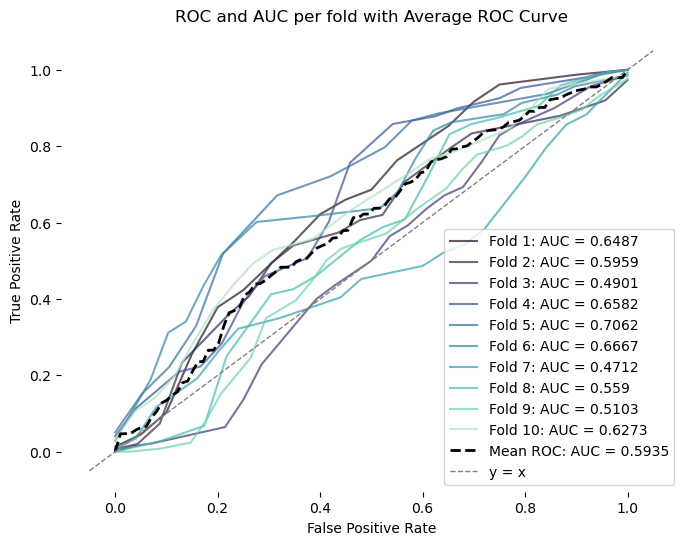

In [ ]:
auc_per_fold(fold_results, "mako", "../outputs/auc_financial_crisis_trial2.png")

#### Trial 3:
- crisis_quarter = "20080930"
- before_crisis_quarter = "20080630"
- crisis_var = "REVENUE"
- nr_quarters_before_crisis = 2
- bottom_quartile = 0.25
- top_quartile = 0.75
- metrics = [col for col in df_9c.columns if col.upper() == col]
- quarters_list = range(2,9,2) 

In [43]:
crisis_quarter = "20080930"
before_crisis_quarter = "20080630"
crisis_var = "REVENUE"
nr_quarters_before_crisis = 6
bottom_quartile = 0.25
top_quartile = 0.75

metrics = [col for col in df_9c.columns if col.upper() == col]
quarters_list = range(2,9,2) 

In [44]:
df_cv_results, fold_results, df_features_aux = combine_analysis(crisis_quarter, before_crisis_quarter, crisis_var, nr_quarters_before_crisis, bottom_quartile, top_quartile, metrics, quarters_list)

C:\Users\joaof\AppData\Local\Temp\ipykernel_31788\2110693337.py:35: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_aux[top_key] = df_aux["id"].map(growth_dict)
C:\Users\joaof\AppData\Local\Temp\ipykernel_31788\2110693337.py:35: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_aux[top_key] = df_aux["id"].map(growth_dict)
C:\Users\joaof\AppData\Local\Temp\ipykernel_31788\2110693337.py:35: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performan

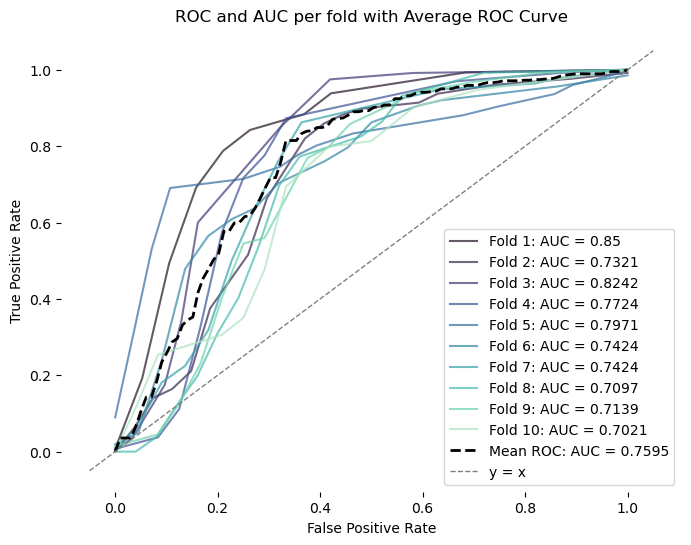

In [ ]:
auc_per_fold(fold_results, "mako", "../outputs/auc_financial_crisis_trial3.png")

#### Trial 4:
- crisis_quarter = "20080930"
- before_crisis_quarter = "20080630"
- crisis_var = "REVENUE"
- nr_quarters_before_crisis = 2
- bottom_quartile = 0.25
- top_quartile = 0.75
- metrics = [col for col in df_9c.columns if col.upper() == col]
- quarters_list = None

In [46]:
crisis_quarter = "20080930"
before_crisis_quarter = "20080630"
crisis_var = "REVENUE"
nr_quarters_before_crisis = 6
bottom_quartile = 0.25
top_quartile = 0.75

metrics = [col for col in df_9c.columns if col.upper() == col]
quarters_list = None

In [47]:
df_cv_results, fold_results, df_features_aux = combine_analysis(crisis_quarter, before_crisis_quarter, crisis_var, nr_quarters_before_crisis, bottom_quartile, top_quartile, metrics, quarters_list)

c:\Users\joaof\anaconda3\envs\nlp\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\joaof\anaconda3\envs\nlp\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.h

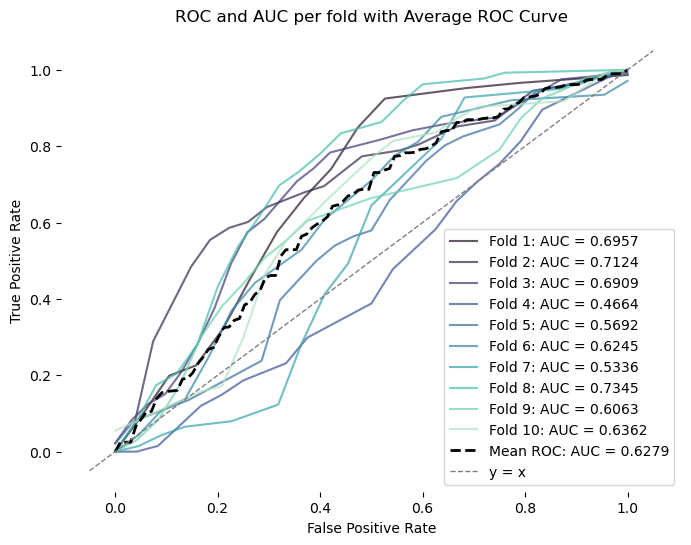

In [ ]:
auc_per_fold(fold_results, "mako", "../outputs/auc_financial_crisis_trial4.png")

## Covid pandemic

#### Trial 1

In [49]:
crisis_quarter = "20210930"
before_crisis_quarter = "20210630"
crisis_var = "REVENUE"
nr_quarters_before_crisis = 1
bottom_quartile = 0.25
top_quartile = 0.75

metrics = [col for col in df_9c.columns if col.upper() == col]
quarters_list = None

c:\Users\joaof\anaconda3\envs\nlp\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\joaof\anaconda3\envs\nlp\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.h

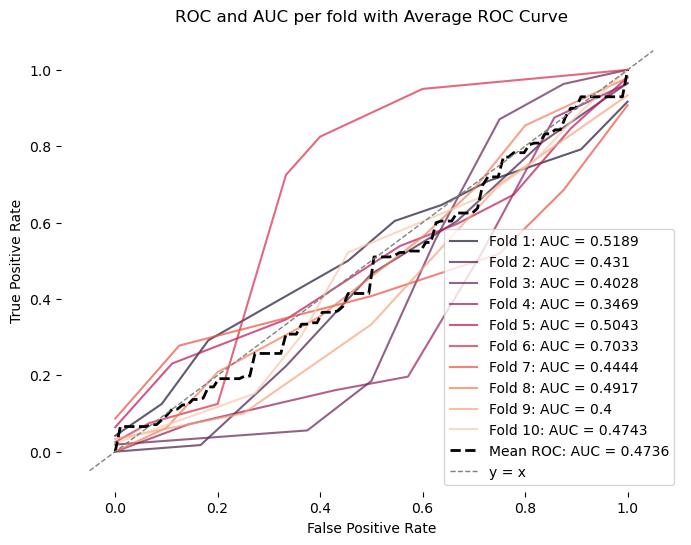

In [ ]:
df_cv_results, fold_results, df_features_aux = combine_analysis(crisis_quarter, before_crisis_quarter, crisis_var, nr_quarters_before_crisis, bottom_quartile, top_quartile, metrics, quarters_list)
auc_per_fold(fold_results, "rocket", "../outputs/auc_covid_crisis_trial1.png")
# auc_per_fold(fold_results, "mako", "../outputs/auc_financial_crisis_trial1.png")

#### Trial 2

In [51]:
crisis_quarter = "20210930"
before_crisis_quarter = "20210630"
crisis_var = "REVENUE"
nr_quarters_before_crisis = 1
bottom_quartile = 0.25
top_quartile = 0.75

metrics = [col for col in df_9c.columns if col.upper() == col]
quarters_list = range(2,9,2) 

C:\Users\joaof\AppData\Local\Temp\ipykernel_31788\2110693337.py:35: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_aux[top_key] = df_aux["id"].map(growth_dict)
C:\Users\joaof\AppData\Local\Temp\ipykernel_31788\2110693337.py:35: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_aux[top_key] = df_aux["id"].map(growth_dict)
C:\Users\joaof\AppData\Local\Temp\ipykernel_31788\2110693337.py:35: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performan

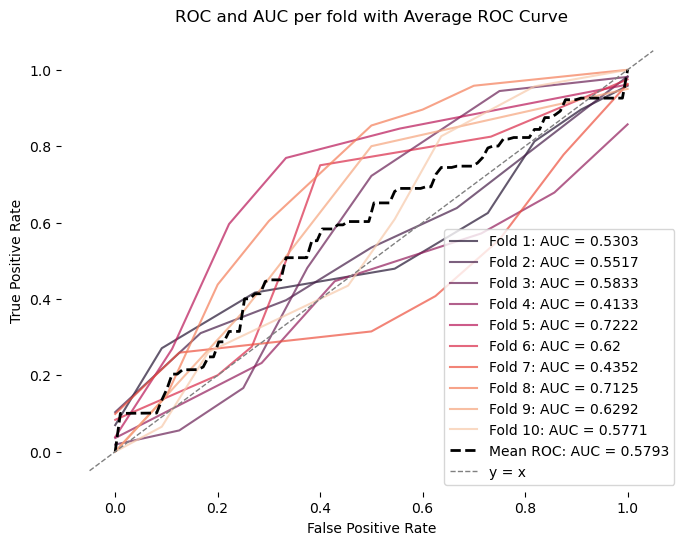

In [ ]:
df_cv_results, fold_results, df_features_aux = combine_analysis(crisis_quarter, before_crisis_quarter, crisis_var, nr_quarters_before_crisis, bottom_quartile, top_quartile, metrics, quarters_list)
auc_per_fold(fold_results, "rocket", "../outputs/auc_covid_crisis_trial2.png")

#### Trial 3:


In [53]:
crisis_quarter = "20210930"
before_crisis_quarter = "20210630"
crisis_var = "REVENUE"
nr_quarters_before_crisis = 6
bottom_quartile = 0.25
top_quartile = 0.75

metrics = [col for col in df_9c.columns if col.upper() == col]
quarters_list = range(2,9,2) 

C:\Users\joaof\AppData\Local\Temp\ipykernel_31788\2110693337.py:35: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_aux[top_key] = df_aux["id"].map(growth_dict)
C:\Users\joaof\AppData\Local\Temp\ipykernel_31788\2110693337.py:35: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_aux[top_key] = df_aux["id"].map(growth_dict)
C:\Users\joaof\AppData\Local\Temp\ipykernel_31788\2110693337.py:35: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performan

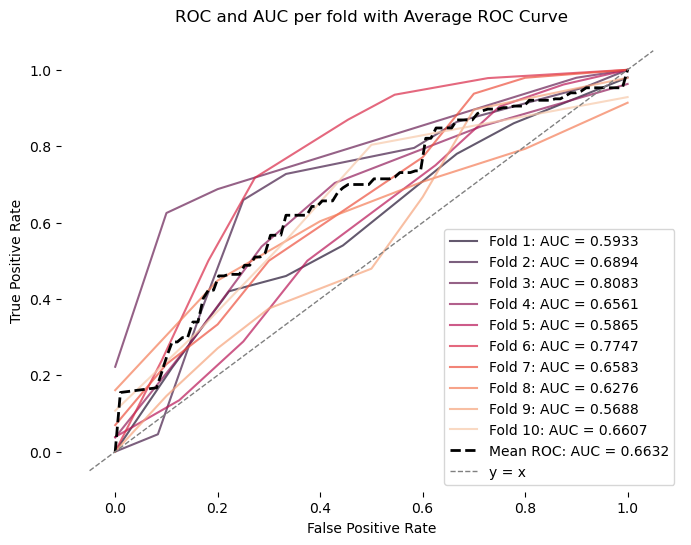

In [ ]:
df_cv_results, fold_results, df_features_aux = combine_analysis(crisis_quarter, before_crisis_quarter, crisis_var, nr_quarters_before_crisis, bottom_quartile, top_quartile, metrics, quarters_list)
auc_per_fold(fold_results, "rocket", "../outputs/auc_covid_crisis_trial3.png")

### Trial 4:

In [55]:
crisis_quarter = "20210930"
before_crisis_quarter = "20210630"
crisis_var = "REVENUE"
nr_quarters_before_crisis = 6
bottom_quartile = 0.25
top_quartile = 0.75

metrics = [col for col in df_9c.columns if col.upper() == col]
quarters_list = None

c:\Users\joaof\anaconda3\envs\nlp\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\joaof\anaconda3\envs\nlp\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.h

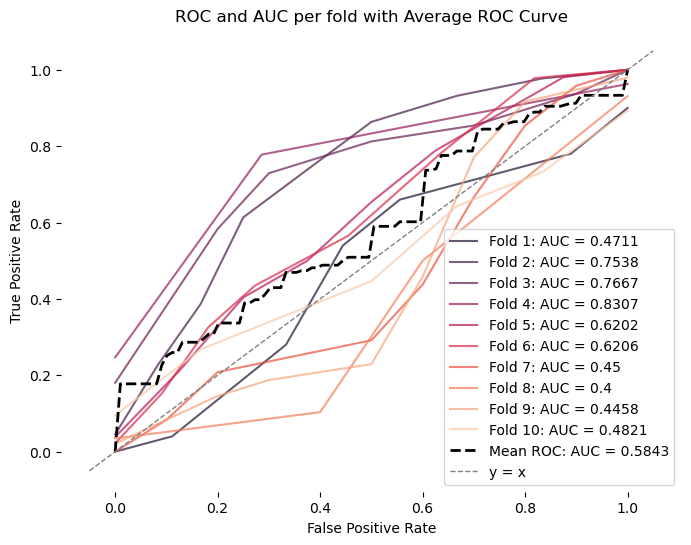

In [ ]:
df_cv_results, fold_results, df_features_aux = combine_analysis(crisis_quarter, before_crisis_quarter, crisis_var, nr_quarters_before_crisis, bottom_quartile, top_quartile, metrics, quarters_list)
auc_per_fold(fold_results, "rocket", "../outputs/auc_covid_crisis_trial4.png")

## Estimate correlations

In [57]:
cols_to_consider = [
    col for col in df_new.columns if ("CUMMULATIVE" not in col) and (col.upper() == col)
]


corr = df_new.loc[:, cols_to_consider].iloc[:, 4:].corr().stack().reset_index()
corr.columns = ["var1", "var2", "correlation"]

# Sort variable names in each pair to ignore order
corr[["var1", "var2"]] = corr[["var1", "var2"]].apply(
    lambda row: sorted(row), axis=1, result_type="expand"
)

# Drop duplicates (since now var1-var2 and var2-var1 are the same)
corr = corr.drop_duplicates()

# Remove self-correlations
corr = corr[corr["var1"] != corr["var2"]]

# Optional: filter by threshold
filtered = corr[corr["correlation"] > 0.8]

In [58]:
corr.sort_values(by="correlation")

,var1,var2,correlation
124,ASSETS_INVESTMENT_NONBANKSUBSIDIARY_EQUITY_FRY9SP,NET_INCOME_FRY9LP,-0.318648
756,ASSETS_INVESTMENT_NONBANKSUBSIDIARY_EQUITY_FRY9SP,EBT_FRY9C,-0.309697
2317,ASSETS_INVESTMENT_BANK_SUBSIDIARY_EQUITY_FRY9SP,ASSETS_INVESTMENT_HOLDINGSUBSIDIARY_EQUITY_FRY9SP,-0.185029
736,ASSETS_CASH_FRY9SP,EBT_FRY9C,-0.137070
104,ASSETS_CASH_FRY9SP,NET_INCOME_FRY9LP,-0.132359
...,...,...,...
179,EBT_FRY9SP,NET_INCOME_BEF_UND_RUB_FRY9SP,0.991589
5366,RATIO_TIER_1_CAPITAL_FRY9C,RATIO_TOTAL_CAPITAL_FRY9C,0.998666
5295,RATIO_TIER_1_LEVERAGE_FRY9C,RATIO_TOTAL_CAPITAL_FRY9C,0.998666
504,ASSETS_TOTALASSETS_FRY9LP,TOTAL_ASSETS_FRY9LP,1.000000


In [59]:
filtered.sort_values(by="correlation")

,var1,var2,correlation
2666,ASSETS_FEDERALFUNDS_RESELL_FRY9C,ASSETS_FIXEDASSETS_FRY9C,0.800185
562,ASSETS_OTHERASSETS_FRY9C,TOTAL_EQUITY_FRY9C,0.801931
5297,RATIO_COMMON_EQUITY_TIER1_CAPITAL_FRY9C,RATIO_TIER_1_LEVERAGE_FRY9C,0.801949
5437,RATIO_COMMON_EQUITY_TIER1_CAPITAL_FRY9C,RATIO_TIER_1_CAPITAL_FRY9C,0.801949
1938,ASSETS_INVESTMENTS_SUBSIDIARIES_FRY9C,ASSETS_LOANSRECEIVABLES_INVESTMENT_FRY9C,0.802535
...,...,...,...
179,EBT_FRY9SP,NET_INCOME_BEF_UND_RUB_FRY9SP,0.991589
5366,RATIO_TIER_1_CAPITAL_FRY9C,RATIO_TOTAL_CAPITAL_FRY9C,0.998666
5295,RATIO_TIER_1_LEVERAGE_FRY9C,RATIO_TOTAL_CAPITAL_FRY9C,0.998666
504,ASSETS_TOTALASSETS_FRY9LP,TOTAL_ASSETS_FRY9LP,1.000000


In [60]:
df.sort_values(by=["id", "quarter"])

,id,country,legal_name,quarter,REVENUE_FRY9C,REVENUE_FRY9SP,REVENUE_FRY9LP,NET_INCOME_FRY9C,NET_INCOME_FRY9SP,NET_INCOME_FRY9LP,...,RECOVERIES_FOREIGN_GOV_FRY9C,RECOVERIES_LEASE_FINANCING_FRY9C,RATIO_CAPITAL_CONSERVATION_BUFFER_FRY9C,RATIO_TIER_1_LEVERAGE_FRY9C,RATIO_TOTAL_CAPITAL_FRY9C,RATIO_TIER_1_CAPITAL_FRY9C,RATIO_COMMON_EQUITY_TIER1_CAPITAL_FRY9C,year,month,nr_quarter
314775,1020180,UNITED STATES,BREMER FINANCIAL CORPORATION,20000331,85127.0,0.0,10360.0,11016.0,0.0,11016.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2000,3,1
308921,1020180,UNITED STATES,BREMER FINANCIAL CORPORATION,20000630,176673.0,0.0,24304.0,22079.0,0.0,22079.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2000,6,2
306773,1020180,UNITED STATES,BREMER FINANCIAL CORPORATION,20000930,272131.0,0.0,31624.0,33754.0,0.0,33754.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2000,9,3
300917,1020180,UNITED STATES,BREMER FINANCIAL CORPORATION,20001231,368388.0,0.0,52966.0,45781.0,0.0,45781.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2000,12,4
298721,1020180,UNITED STATES,BREMER FINANCIAL CORPORATION,20010331,94175.0,0.0,13907.0,11174.0,0.0,11174.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2001,3,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3740,6006899,UNITED STATES,"WINCHESTER BANCORP, MHC",20250630,0.0,0.0,0.0,0.0,-338.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2025,6,2
3741,6007421,UNITED STATES,"WINCHESTER BANCORP, INC.",20250630,0.0,100.0,0.0,0.0,-615.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2025,6,2
3742,6010430,UNITED STATES,LINDSEY FAMILY TRUST,20250630,0.0,0.0,0.0,0.0,212.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2025,6,2
3743,6030278,UNITED STATES,FIRST SOUTHERN NATIONAL BANCSHARES INC,20250630,0.0,3000.0,0.0,0.0,11362.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2025,6,2
